In [20]:
import gym
from gym import spaces
import numpy as np
import random
import matplotlib.pyplot as plt
import pickle


Deterministic environment


In [22]:
class DeterministicEnv(gym.Env):
    def __init__(self):
        super(DeterministicEnv, self).__init__()
        # Grid dimensions: 4 rows x 5 columns = 20 states.
        self.grid_rows = 4
        self.grid_cols = 5
        
        # 4 discrete actions: 0: up, 1: right, 2: down, 3: left.
        self.action_space = spaces.Discrete(4)
        # Observation space: 2D coordinate (row, col).
        self.observation_space = spaces.MultiDiscrete([self.grid_rows, self.grid_cols])
        
        # Define key cells: goal and special cell.
        self.goal_state = (self.grid_rows - 1, self.grid_cols - 1)  # Bottom-right cell.
        self.special_state = (2, 2)  # Special cell.
        
        # Maximum steps per episode.
        self.max_steps = 50
        self.current_step = 0
        
        # Initial state.
        self.state = (0, 0)
    
    def reset(self):
        self.state = (0, 0)
        self.current_step = 0
        return np.array(self.state)
    
    def step(self, action):
        self.current_step += 1
        row, col = self.state
        
        # Determine next state based on the chosen action.
        if action == 0:    # Up
            next_state = (max(row - 1, 0), col)
        elif action == 1:  # Right
            next_state = (row, min(col + 1, self.grid_cols - 1))
        elif action == 2:  # Down
            next_state = (min(row + 1, self.grid_rows - 1), col)
        elif action == 3:  # Left
            next_state = (row, max(col - 1, 0))
        else:
            next_state = self.state
        
        # Reward structure with a baseline penalty (-0.1 per move):
        reward = -0.1
        if next_state == self.state:
            reward -= 0.9  # Hitting a wall: total reward -1.0.
        elif next_state == self.goal_state:
            reward = 10.0  # Reaching the goal.
        elif next_state == self.special_state:
            reward = 2.0   # Special cell reward.
        else:
            reward += 1.0  # Normal move: net reward +0.9.
        
        self.state = next_state
        done = (self.state == self.goal_state) or (self.current_step >= self.max_steps)
        return np.array(self.state), reward, done, {}
    
    def render(self, mode='human'):
        # Create a grid with 4 integer values:
        # 0 = empty, 1 = agent, 2 = goal, 3 = special.
        grid = np.zeros((self.grid_rows, self.grid_cols), dtype=int)
        sr, sc = self.special_state
        grid[sr, sc] = 3  # Mark special cell.
        gr, gc = self.goal_state
        grid[gr, gc] = 2  # Mark goal.
        r, c = self.state
        grid[r, c] = 1   # Mark agent.
        
        # Define a discrete colormap with 4 colors.
        cmap = plt.cm.get_cmap('Accent', 4)
        plt.figure(figsize=(4,3))
        plt.imshow(grid, cmap=cmap, vmin=0, vmax=3)
        plt.colorbar(ticks=[0, 1, 2, 3], label='Cell Type')
        plt.title("Deterministic Environment Visualization")
        plt.xticks(range(self.grid_cols))
        plt.yticks(range(self.grid_rows))
        plt.show()


Non-Deterministic Environment

In [23]:
class NonDeterministicEnv(DeterministicEnv):
    def __init__(self, slip_prob=0.2):
        super(NonDeterministicEnv, self).__init__()
        self.slip_prob = slip_prob  # Probability to override the chosen action.
    
    def step(self, action):
        # With probability slip_prob, override the chosen action with a random one.
        if random.random() < self.slip_prob:
            action = self.action_space.sample()
        return super().step(action)
    
    def render(self, mode='human'):
        # Use the same grid layout but change the title to reflect nondeterminism.
        grid = np.zeros((self.grid_rows, self.grid_cols), dtype=int)
        sr, sc = self.special_state
        grid[sr, sc] = 3
        gr, gc = self.goal_state
        grid[gr, gc] = 2
        r, c = self.state
        grid[r, c] = 1
        cmap = plt.cm.get_cmap('Accent', 4)
        plt.figure(figsize=(4,3))
        plt.imshow(grid, cmap=cmap, vmin=0, vmax=3)
        plt.colorbar(ticks=[0, 1, 2, 3], label='Cell Type')
        plt.title("Non-Deterministic Environment Visualization")
        plt.xticks(range(self.grid_cols))
        plt.yticks(range(self.grid_rows))
        plt.show()


----- Deterministic Environment (Random Agent Test) -----
Initial state: [0 0]
Step 1: action=1, state=[0 1], reward=0.9


/var/folders/3b/cm4b_6dj6jx1x67c1tfdzj0c0000gp/T/ipykernel_56886/3666699540.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Accent', 4)


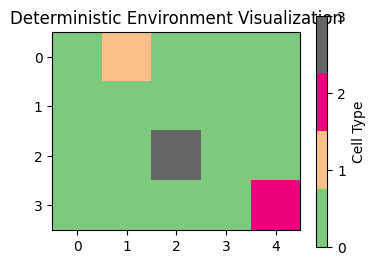

Step 2: action=1, state=[0 2], reward=0.9
Step 3: action=2, state=[1 2], reward=0.9
Step 4: action=3, state=[1 1], reward=0.9
Step 5: action=0, state=[0 1], reward=0.9
Step 6: action=0, state=[0 1], reward=-1.0
Step 7: action=2, state=[1 1], reward=0.9
Step 8: action=3, state=[1 0], reward=0.9
Step 9: action=3, state=[1 0], reward=-1.0
Step 10: action=2, state=[2 0], reward=0.9
Step 11: action=2, state=[3 0], reward=0.9


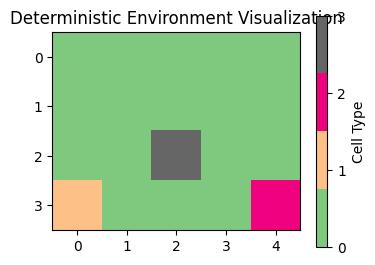

Step 12: action=2, state=[3 0], reward=-1.0
Step 13: action=2, state=[3 0], reward=-1.0
Step 14: action=1, state=[3 1], reward=0.9
Step 15: action=1, state=[3 2], reward=0.9
Step 16: action=1, state=[3 3], reward=0.9
Step 17: action=0, state=[2 3], reward=0.9
Step 18: action=1, state=[2 4], reward=0.9
Step 19: action=0, state=[1 4], reward=0.9
Step 20: action=0, state=[0 4], reward=0.9
Step 21: action=1, state=[0 4], reward=-1.0


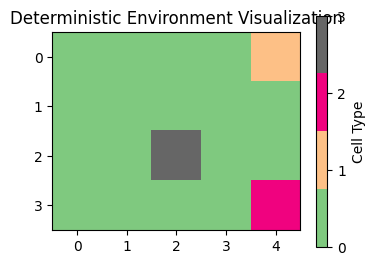

Step 22: action=1, state=[0 4], reward=-1.0
Step 23: action=3, state=[0 3], reward=0.9
Step 24: action=3, state=[0 2], reward=0.9
Step 25: action=3, state=[0 1], reward=0.9
Step 26: action=1, state=[0 2], reward=0.9
Step 27: action=0, state=[0 2], reward=-1.0
Step 28: action=2, state=[1 2], reward=0.9
Step 29: action=1, state=[1 3], reward=0.9
Step 30: action=0, state=[0 3], reward=0.9
Step 31: action=0, state=[0 3], reward=-1.0


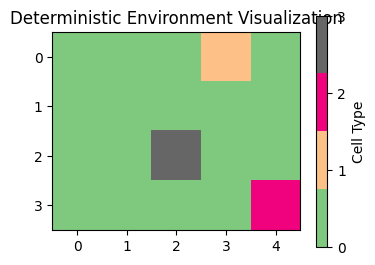

Step 32: action=3, state=[0 2], reward=0.9
Step 33: action=1, state=[0 3], reward=0.9
Step 34: action=2, state=[1 3], reward=0.9
Step 35: action=2, state=[2 3], reward=0.9
Step 36: action=0, state=[1 3], reward=0.9
Step 37: action=3, state=[1 2], reward=0.9
Step 38: action=1, state=[1 3], reward=0.9
Step 39: action=1, state=[1 4], reward=0.9
Step 40: action=2, state=[2 4], reward=0.9

----- Non-Deterministic Environment (Random Agent Test) -----
Initial state: [0 0]
Step 1: action=0, state=[0 0], reward=-1.0


/var/folders/3b/cm4b_6dj6jx1x67c1tfdzj0c0000gp/T/ipykernel_56886/89379491.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Accent', 4)


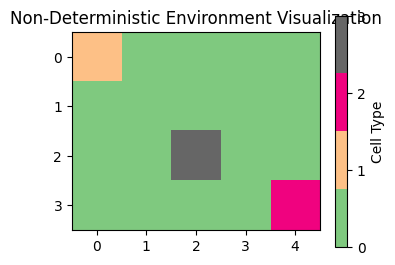

Step 2: action=3, state=[0 0], reward=-1.0
Step 3: action=3, state=[0 0], reward=-1.0
Step 4: action=0, state=[0 0], reward=-1.0
Step 5: action=1, state=[0 1], reward=0.9
Step 6: action=1, state=[0 2], reward=0.9
Step 7: action=0, state=[0 2], reward=-1.0
Step 8: action=2, state=[0 3], reward=0.9
Step 9: action=1, state=[0 4], reward=0.9
Step 10: action=1, state=[0 4], reward=-1.0
Step 11: action=1, state=[0 4], reward=-1.0


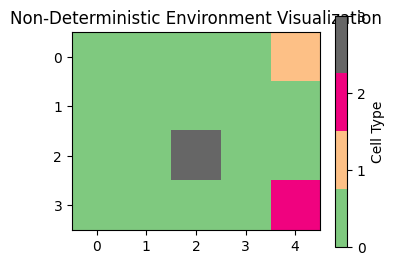

Step 12: action=1, state=[0 4], reward=-1.0
Step 13: action=1, state=[0 4], reward=-1.0
Step 14: action=0, state=[0 4], reward=-1.0
Step 15: action=0, state=[0 4], reward=-1.0
Step 16: action=1, state=[0 4], reward=-1.0
Step 17: action=3, state=[0 3], reward=0.9
Step 18: action=3, state=[0 2], reward=0.9
Step 19: action=0, state=[0 2], reward=-1.0
Step 20: action=2, state=[1 2], reward=0.9
Step 21: action=0, state=[1 1], reward=0.9


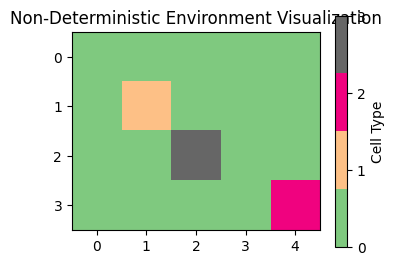

Step 22: action=0, state=[0 1], reward=0.9
Step 23: action=3, state=[0 0], reward=0.9
Step 24: action=0, state=[0 0], reward=-1.0
Step 25: action=1, state=[0 1], reward=0.9
Step 26: action=2, state=[1 1], reward=0.9
Step 27: action=0, state=[2 1], reward=0.9
Step 28: action=1, state=[3 1], reward=0.9
Step 29: action=0, state=[2 1], reward=0.9
Step 30: action=1, state=[2 2], reward=2.0
Step 31: action=0, state=[1 2], reward=0.9


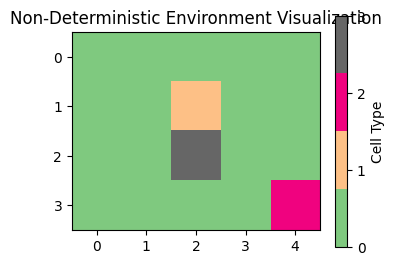

Step 32: action=3, state=[1 1], reward=0.9
Step 33: action=3, state=[1 0], reward=0.9
Step 34: action=3, state=[1 0], reward=-1.0
Step 35: action=1, state=[1 1], reward=0.9
Step 36: action=0, state=[0 1], reward=0.9
Step 37: action=2, state=[1 1], reward=0.9
Step 38: action=1, state=[1 2], reward=0.9
Step 39: action=0, state=[0 2], reward=0.9
Step 40: action=0, state=[0 2], reward=-1.0


In [4]:
def run_random_agent(env, timesteps=40):
    state = env.reset()
    print("Initial state:", state)
    for t in range(timesteps):
        action = env.action_space.sample()
        state, reward, done, _ = env.step(action)
        print(f"Step {t+1}: action={action}, state={state}, reward={reward}")
        # Render the grid every 10 steps for visualization.
        if t % 10 == 0:
            env.render()
        if done:
            print("Episode ended (goal reached or max steps).")
            break

print("----- Deterministic Environment (Random Agent Test) -----")
det_env = DeterministicEnv()
run_random_agent(det_env)

print("\n----- Non-Deterministic Environment (Random Agent Test) -----")
nondet_env = NonDeterministicEnv(slip_prob=0.2)
run_random_agent(nondet_env)


Q-Learning functions

In [ ]:
def state_to_index(state, grid_cols):
    # Convert a (row, col) state into a single index.
    return state[0] * grid_cols + state[1]

def q_learning(env, episodes, alpha, gamma,
               epsilon, epsilon_decay, min_epsilon):
    num_states = env.grid_rows * env.grid_cols
    num_actions = env.action_space.n
    Q = np.zeros((num_states, num_actions))
    episode_rewards = []
    epsilons = []
    
    for ep in range(episodes):
        state = env.reset()
        state_idx = state_to_index(state, env.grid_cols)
        total_reward = 0
        done = False
        
        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state_idx])
            next_state, reward, done, _ = env.step(action)
            next_state_idx = state_to_index(next_state, env.grid_cols)
            best_next = np.max(Q[next_state_idx])
            Q[state_idx, action] += alpha * (reward + gamma * best_next - Q[state_idx, action])
            state_idx = next_state_idx
            total_reward += reward
        
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)
        epsilons.append(epsilon)
    
    return Q, episode_rewards, epsilons


In [ ]:
#Hyperparameters initialization
alpha_1 = 0.5
gamma_1= 0.9
epsilon_1 = 1.0
epsilon_decay_1 = 0.99
min_epsilon_1 = 0.01
episodes_1 = 500

#second set of parametes
alpha_2 = 0.4   
gamma_2 = 0.8
epsilon_2 = 0.9
epsilon_decay_2 = 0.95
min_epsilon_2 = 0.05
episodes_2 = 1000

alpha_3 = 0.3
gamma_3 = 0.7
epsilon_3 = 0.8
epsilon_decay_3 = 0.9
min_epsilon_3 = 0.2
episodes_3 = 300

# Train on Deterministic Environment.
det_Q1, det_rewards1, det_epsilons1 = q_learning(det_env, episodes_1, alpha_1, gamma_1, epsilon_1, epsilon_decay_1, min_epsilon_1)

# Train on Non-Deterministic Environment.
nondet_Q1, nondet_rewards1, nondet_epsilons1 = q_learning(nondet_env, episodes_1, alpha_2, gamma_2, epsilon_2, epsilon_decay_2, min_epsilon_2)

det_Q2, det_rewards2, det_epsilons2 = q_learning(det_env, episodes_2, alpha_1, gamma_1, epsilon_1, epsilon_decay_1, min_epsilon_1)

nondet_Q2, nondet_rewards2, nondet_epsilons2 = q_learning(nondet_env, episodes_2, alpha_2, gamma_2, epsilon_2, epsilon_decay_2, min_epsilon_2)

det_Q3, det_rewards3, det_epsilons3 = q_learning(det_env, episodes_3, alpha_3, gamma_3, epsilon_3, epsilon_decay_3, min_epsilon_3)

nondet_Q3, nondet_rewards3, nondet_epsilons3 = q_learning(nondet_env, episodes_3, alpha_3, gamma_3, epsilon_3, epsilon_decay_3, min_epsilon_3)


#Save the trained models

with open("deterministic_Q_set1.pkl", "wb") as f:
    pickle.dump(det_Q1, f)
with open("nondeterministic_Q_set1.pkl", "wb") as f:
    pickle.dump(nondet_Q1, f)

with open("deterministic_Q_set2.pkl", "wb") as f:
    pickle.dump(det_Q2, f)
with open("nondeterministic_Q_set2.pkl", "wb") as f:
    pickle.dump(nondet_Q2, f)

with open("deterministic_Q_set3.pkl", "wb") as f:
    pickle.dump(det_Q3, f)
with open("nondeterministic_Q_set3.pkl", "wb") as f:
    pickle.dump(nondet_Q3, f)


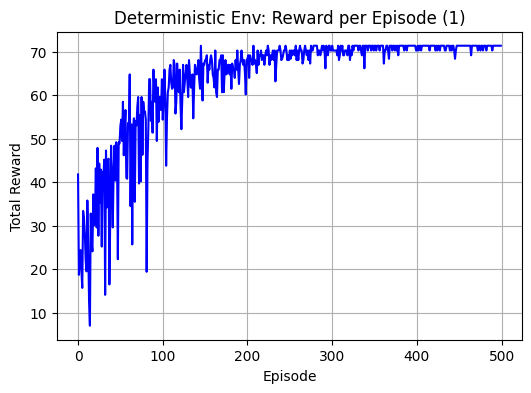

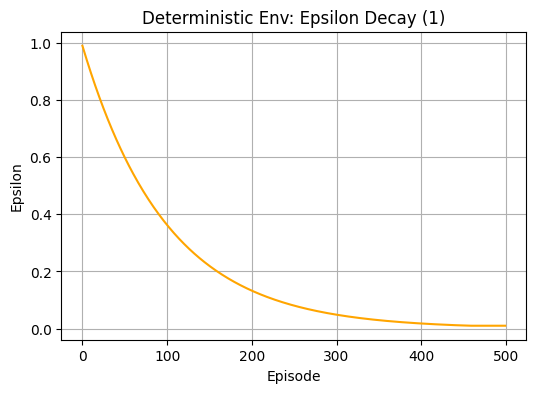

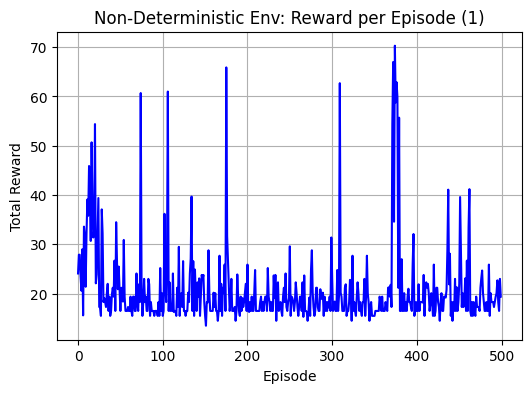

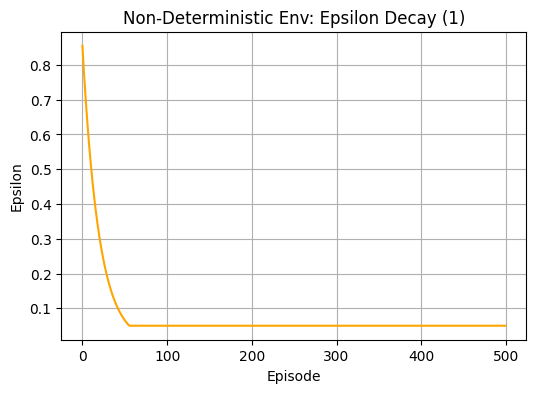

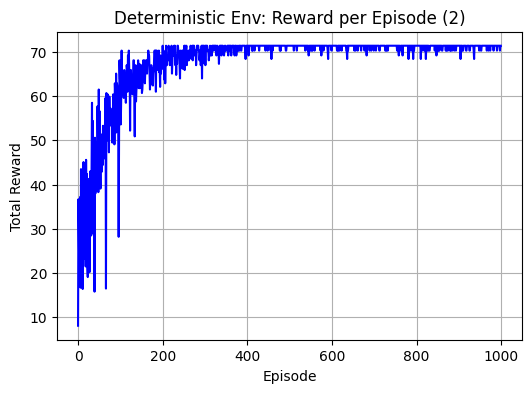

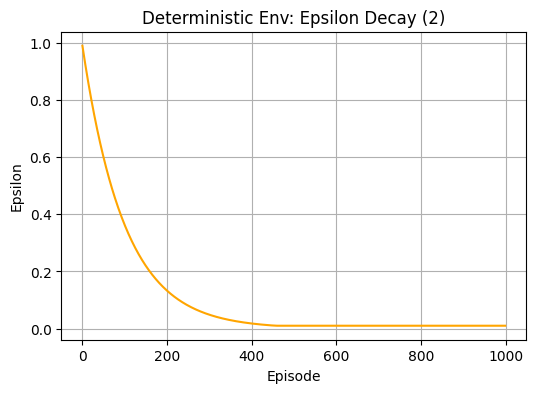

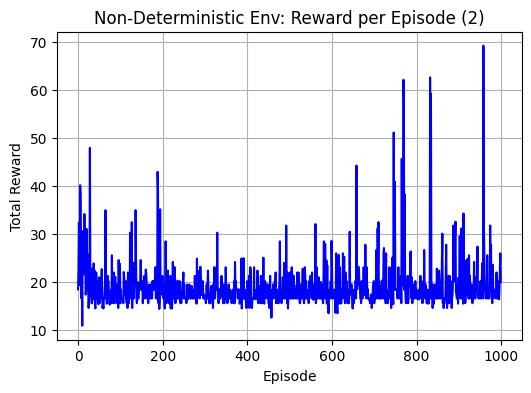

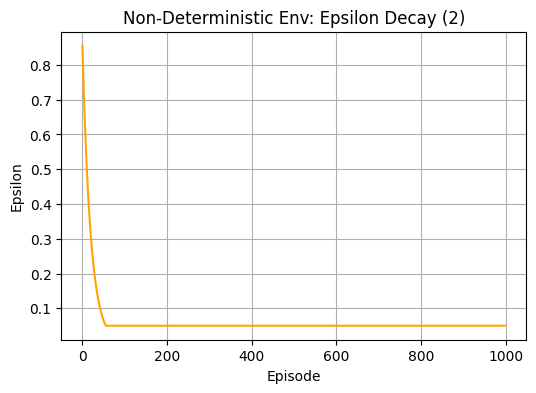

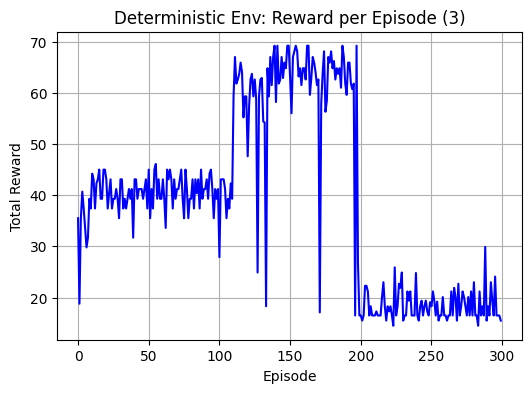

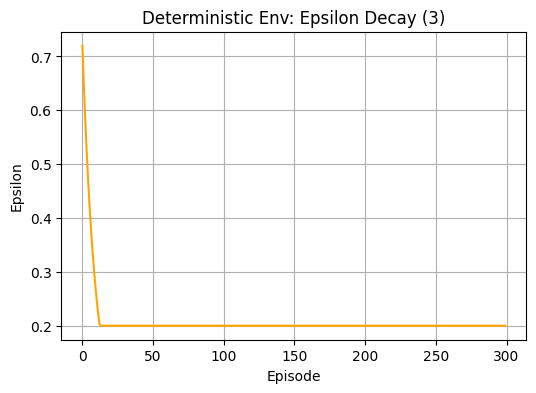

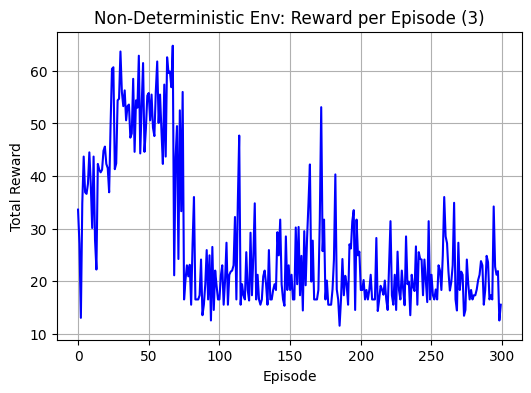

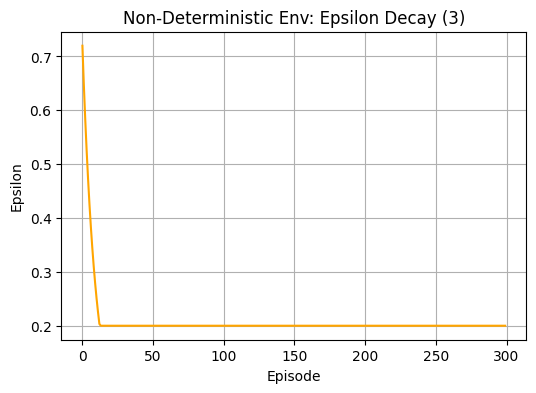

In [19]:
# Plot for Deterministic Environment: Reward per Episode.
plt.figure(figsize=(6,4))
plt.plot(det_rewards1, color='blue')
plt.title("Deterministic Env: Reward per Episode (1)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

# Plot for Deterministic Environment: Epsilon Decay.
plt.figure(figsize=(6,4))
plt.plot(det_epsilons1, color='orange')
plt.title("Deterministic Env: Epsilon Decay (1)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()

# Plot for Non-Deterministic Environment: Reward per Episode.
plt.figure(figsize=(6,4))
plt.plot(nondet_rewards1, color='blue')
plt.title("Non-Deterministic Env: Reward per Episode (1)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

# Plot for Non-Deterministic Environment: Epsilon Decay.
plt.figure(figsize=(6,4))
plt.plot(nondet_epsilons1, color='orange')
plt.title("Non-Deterministic Env: Epsilon Decay (1)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()


#second set of parametes plots
# Plot for Deterministic Environment: Reward per Episode.
plt.figure(figsize=(6,4))
plt.plot(det_rewards2, color='blue')
plt.title("Deterministic Env: Reward per Episode (2)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

# Plot for Deterministic Environment: Epsilon Decay.
plt.figure(figsize=(6,4))
plt.plot(det_epsilons2, color='orange')
plt.title("Deterministic Env: Epsilon Decay (2)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()

# Plot for Non-Deterministic Environment: Reward per Episode.
plt.figure(figsize=(6,4))
plt.plot(nondet_rewards2, color='blue')
plt.title("Non-Deterministic Env: Reward per Episode (2)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

# Plot for Non-Deterministic Environment: Epsilon Decay.
plt.figure(figsize=(6,4))
plt.plot(nondet_epsilons2, color='orange')
plt.title("Non-Deterministic Env: Epsilon Decay (2)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()



#third set of parameters plot

# Plot for Deterministic Environment: Reward per Episode.
plt.figure(figsize=(6,4))
plt.plot(det_rewards3, color='blue')
plt.title("Deterministic Env: Reward per Episode (3)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

# Plot for Deterministic Environment: Epsilon Decay.
plt.figure(figsize=(6,4))
plt.plot(det_epsilons3, color='orange')
plt.title("Deterministic Env: Epsilon Decay (3)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()

# Plot for Non-Deterministic Environment: Reward per Episode.
plt.figure(figsize=(6,4))
plt.plot(nondet_rewards3, color='blue')
plt.title("Non-Deterministic Env: Reward per Episode (3)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

# Plot for Non-Deterministic Environment: Epsilon Decay.
plt.figure(figsize=(6,4))
plt.plot(nondet_epsilons3, color='orange')
plt.title("Non-Deterministic Env: Epsilon Decay (3)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()




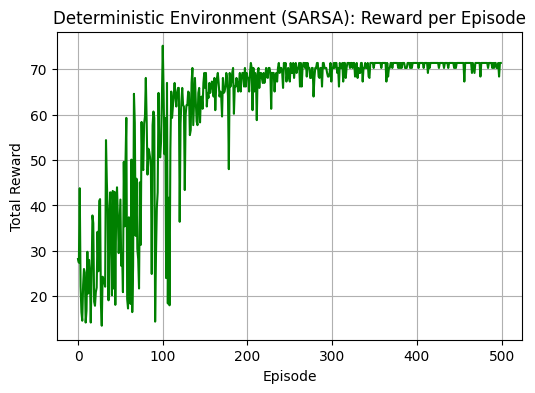

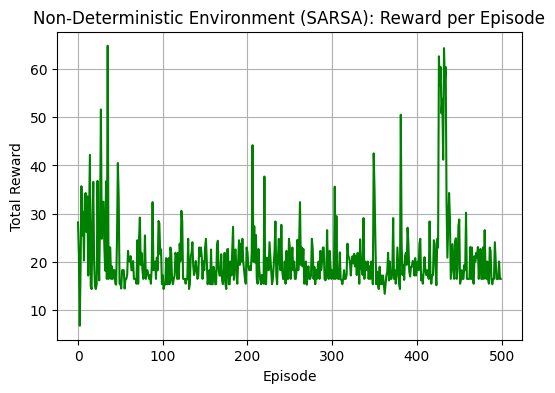

In [30]:
# %%
def sarsa(env, episodes, alpha, gamma, epsilon, epsilon_decay, min_epsilon):
    num_states = env.grid_rows * env.grid_cols
    num_actions = env.action_space.n
    Q = np.zeros((num_states, num_actions))
    episode_rewards = []
    
    for ep in range(episodes):
        state = env.reset()
        state_idx = state_to_index(state, env.grid_cols)
        # Choose initial action using epsilon-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state_idx])
        total_reward = 0
        done = False
        
        while not done:
            next_state, reward, done, _ = env.step(action)
            next_state_idx = state_to_index(next_state, env.grid_cols)
            # Choose next action using epsilon-greedy
            if random.random() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax(Q[next_state_idx])
            # SARSA update
            Q[state_idx, action] += alpha * (reward + gamma * Q[next_state_idx, next_action] - Q[state_idx, action])
            state_idx = next_state_idx
            action = next_action
            total_reward += reward
        
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)
    
    return Q, episode_rewards

# SARSA hyperparameters for the deterministic environment
alpha_sarsa_det = 0.5
gamma_sarsa_det = 0.9
epsilon_sarsa_det = 1.0
epsilon_decay_sarsa_det = 0.99
min_epsilon_sarsa_det = 0.01
episodes_sarsa_det = 500

# SARSA hyperparameters for the non-deterministic environment
alpha_sarsa_nondet = 0.4
gamma_sarsa_nondet = 0.8
epsilon_sarsa_nondet = 1.0
epsilon_decay_sarsa_nondet = 0.95
min_epsilon_sarsa_nondet = 0.05
episodes_sarsa_nondet = 500

# Train SARSA on the deterministic environment
sarsa_det_Q, sarsa_det_rewards = sarsa(
    det_env, episodes_sarsa_det, 
    alpha_sarsa_det, gamma_sarsa_det, 
    epsilon_sarsa_det, epsilon_decay_sarsa_det, 
    min_epsilon_sarsa_det
)

# Train SARSA on the non-deterministic environment
sarsa_nondet_Q, sarsa_nondet_rewards = sarsa(
    nondet_env, episodes_sarsa_nondet, 
    alpha_sarsa_nondet, gamma_sarsa_nondet, 
    epsilon_sarsa_nondet, epsilon_decay_sarsa_nondet, 
    min_epsilon_sarsa_nondet
)

# Save SARSA Q-tables
with open("sarsa_det_Q.pkl", "wb") as f:
    pickle.dump(sarsa_det_Q, f)

with open("sarsa_nondet_Q.pkl", "wb") as f:
    pickle.dump(sarsa_nondet_Q, f)

# Plot total reward per episode for SARSA on the deterministic environment
plt.figure(figsize=(6,4))
plt.plot(sarsa_det_rewards, color='green')
plt.title("Deterministic Environment (SARSA): Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

# Plot total reward per episode for SARSA on the non-deterministic environment
plt.figure(figsize=(6,4))
plt.plot(sarsa_nondet_rewards, color='green')
plt.title("Non-Deterministic Environment (SARSA): Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()


Greedy Policy Evaluation (Q-learning) on Deterministic Environment: [71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 71.39999999999998, 

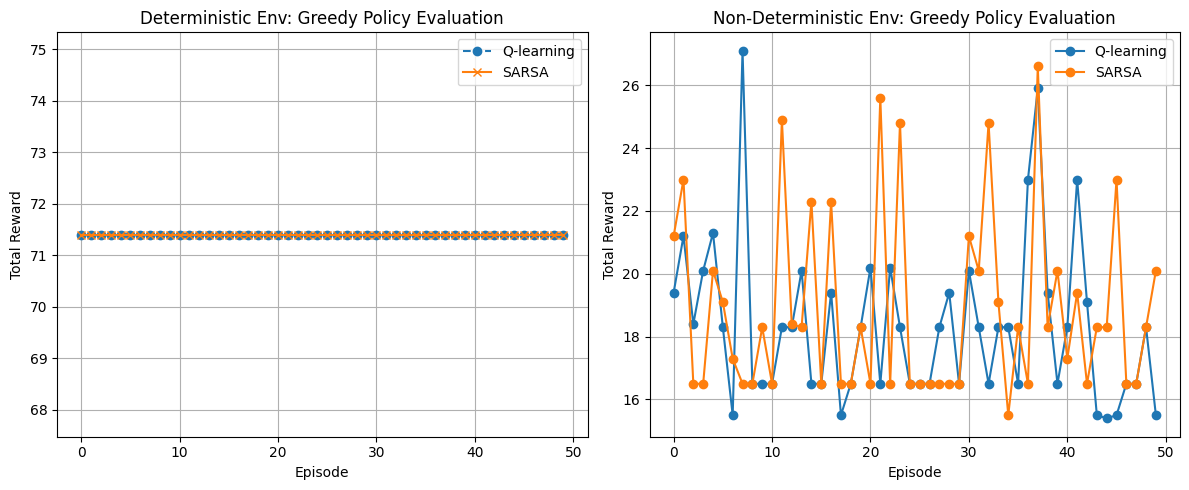

In [34]:
# %%
eval_episodes = 50

# ----- Evaluate Q-learning model (using det_Q1 and nondet_Q1) -----

# Deterministic Environment Evaluation (Q-learning)
det_eval_rewards_q = []
for _ in range(eval_episodes):
    state = det_env.reset()
    state_idx = state_to_index(state, det_env.grid_cols)
    total_reward = 0
    done = False
    while not done:
        action = np.argmax(det_Q1[state_idx])  # Greedy action from Q-learning table (det_Q1)
        next_state, reward, done, _ = det_env.step(action)
        state_idx = state_to_index(next_state, det_env.grid_cols)
        total_reward += reward
    det_eval_rewards_q.append(total_reward)

# Non-Deterministic Environment Evaluation (Q-learning)
nondet_eval_rewards_q = []
for _ in range(eval_episodes):
    state = nondet_env.reset()
    state_idx = state_to_index(state, nondet_env.grid_cols)
    total_reward = 0
    done = False
    while not done:
        action = np.argmax(nondet_Q1[state_idx])  # Greedy action from Q-learning table (nondet_Q1)
        next_state, reward, done, _ = nondet_env.step(action)
        state_idx = state_to_index(next_state, nondet_env.grid_cols)
        total_reward += reward
    nondet_eval_rewards_q.append(total_reward)

print("Greedy Policy Evaluation (Q-learning) on Deterministic Environment:", det_eval_rewards_q)
print("Greedy Policy Evaluation (Q-learning) on Non-Deterministic Environment:", nondet_eval_rewards_q)


# ----- Evaluate SARSA model (using sarsa_det_Q and sarsa_nondet_Q) -----

# Deterministic Environment Evaluation (SARSA)
det_eval_rewards_sarsa = []
for _ in range(eval_episodes):
    state = det_env.reset()
    state_idx = state_to_index(state, det_env.grid_cols)
    total_reward = 0
    done = False
    while not done:
        action = np.argmax(sarsa_det_Q[state_idx])  # Greedy action from SARSA Q-table
        next_state, reward, done, _ = det_env.step(action)
        state_idx = state_to_index(next_state, det_env.grid_cols)
        total_reward += reward
    det_eval_rewards_sarsa.append(total_reward)

# Non-Deterministic Environment Evaluation (SARSA)
nondet_eval_rewards_sarsa = []
for _ in range(eval_episodes):
    state = nondet_env.reset()
    state_idx = state_to_index(state, nondet_env.grid_cols)
    total_reward = 0
    done = False
    while not done:
        action = np.argmax(sarsa_nondet_Q[state_idx])  # Greedy action from SARSA Q-table
        next_state, reward, done, _ = nondet_env.step(action)
        state_idx = state_to_index(next_state, nondet_env.grid_cols)
        total_reward += reward
    nondet_eval_rewards_sarsa.append(total_reward)

print("Greedy Policy Evaluation (SARSA) on Deterministic Environment:", det_eval_rewards_sarsa)
print("Greedy Policy Evaluation (SARSA) on Non-Deterministic Environment:", nondet_eval_rewards_sarsa)


# ----- Plot evaluation results -----

plt.figure(figsize=(12,5))

# Plot for Deterministic Environment
plt.subplot(1,2,1)
plt.plot(det_eval_rewards_q, marker='o', linestyle='--', label="Q-learning")
plt.plot(det_eval_rewards_sarsa, marker='x', linestyle='-', label="SARSA")
plt.title("Deterministic Env: Greedy Policy Evaluation")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)

# Plot for Non-Deterministic Environment
plt.subplot(1,2,2)
plt.plot(nondet_eval_rewards_q, marker='o', linestyle='-', label="Q-learning")
plt.plot(nondet_eval_rewards_sarsa, marker='o', linestyle='-', label="SARSA")
plt.title("Non-Deterministic Env: Greedy Policy Evaluation")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
